# import pips

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

In [ ]:
valid_data = tf.keras.utils.image_dataset_from_directory(
    'valid',                    # Path to validation folder
    label_mode='categorical',   # Multi-class (38 classes → one-hot)
    image_size=(224, 224),      # Resize images
    batch_size=32,              # 32 images per batch
    shuffle=False               # No need to shuffle validation data
)

Found 17572 files belonging to 38 classes.


In [ ]:
class_name = valid_data.class_names
class_name

['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_

# Load Fusion Model

In [ ]:
fusion = tf.keras.models.load_model("leaf.keras", compile=False)

visual Image

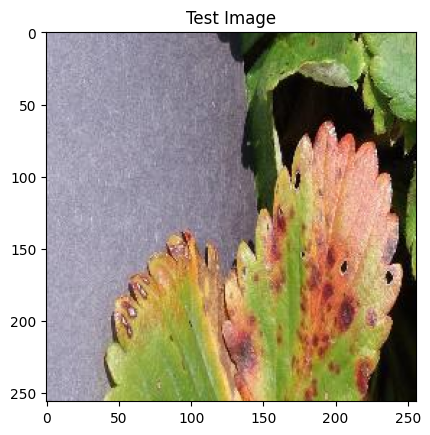

In [ ]:
#Test Image Visualization
import cv2
image_path = 'valid\Peach___healthy\0a4795b0-5144-4dea-a7ed-b6243416e8d0___Rutg._HL 3530_90deg.JPG'
# Reading an image in default mode
img = cv2.imread(image_path)
img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB) #Converting BGR to RGB
# Displaying the image 
plt.imshow(img)
plt.title('Test Image')

plt.show()

Test Model

In [ ]:
image = tf.keras.preprocessing.image.load_img(image_path,target_size=(128,128))
input_arr = tf.keras.preprocessing.image.img_to_array(image)
input_arr = np.array([input_arr])  # Convert single image to a batch.
predictions = fusion.predict(input_arr)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


In [ ]:
print(predictions)

[[6.96445657e-09 1.63813255e-07 4.87333006e-20 7.02488956e-10
  4.71792063e-08 1.61740954e-10 6.00889461e-16 6.47854467e-05
  1.06754668e-10 3.88149282e-08 9.65272220e-12 5.38637112e-19
  8.11112386e-08 1.91463480e-14 5.66097741e-26 6.17968107e-17
  1.33199751e-06 2.66177753e-15 1.50892845e-07 1.93595273e-09
  3.22236066e-15 7.31628893e-21 3.47600060e-10 3.46407808e-19
  1.12501877e-22 2.41585930e-15 9.99932885e-01 1.34178673e-19
  5.81301690e-29 1.05932434e-13 4.82163216e-07 2.88883151e-18
  1.87011891e-13 2.83667212e-21 6.14532817e-12 1.62131931e-22
  4.56632678e-22 1.24695546e-07]]


In [ ]:
result_index = np.argmax(predictions) #Return index of max element
print(result_index)

26


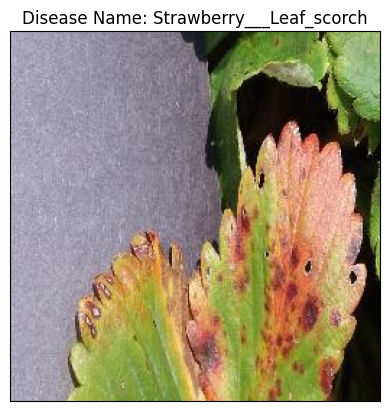

In [ ]:
# Displaying the disease prediction
model_prediction = class_name[result_index]
plt.imshow(img)
plt.title(f"Disease Name: {model_prediction}")
plt.xticks([])
plt.yticks([])
plt.show()